# AMS of the D6A-AGT specimens

Anisotropy of magnetic susceptibility (AMS) for the D-6A AGT specimens, from the IRM database export `D6A-AGT-CS.TXT`. The export is a combined MagIC format file; it is unpacked into its constituent tables and the anisotropy data are plotted following the workflow of the RockmagPy [anisotropy notebook](https://github.com/PmagPy/RockmagPy-notebooks/blob/main/anisotropy_notebooks/anisotropy_plot_AMS.ipynb): 29 specimens have `AMS` tensors (`aniso_s`) with the Jelínek shape parameters (L, F, P, T) already computed.

The exported tensors are in specimen coordinates; they are rotated into geographic coordinates below using the sample orientations before plotting. Because the core is unoriented in azimuth, principal-axis plunges are meaningful for the near-vertical hole while azimuths remain relative. The fabric *shape* parameters (P, T) are coordinate-independent.

*A note on units: the exported `aniso_s` values are Kappabridge volume susceptibilities in units of $10^{-6}$ SI — recoverable here by comparison with the bulk susceptibility measurements, but undeclared in the export. The MagIC data model records the tensor convention in the `aniso_s_unit` column (controlled vocabulary: `SI`, `Am^2`, `m^3/kg`, `Normalized by trace`, `bulk in measurements table`). The plan for the IRM MagIC export is to write trace-normalized tensors with `aniso_s_unit` = `Normalized by trace`, preserving the magnitude in `aniso_s_mean` (in true SI) alongside the bulk susceptibility rows already in the measurements table. The AGICO Kappabridge also measures a bulk susceptibility separately from the anisotropy determination, and this can be added to the export in the correct units in the specimens-table columns `susc_chi_volume` and `susc_chi_mass`.*

*A note on coordinates: the exported tensors are in specimen coordinates, also currently undeclared. The MagIC data model documents the coordinate system with `aniso_tilt_correction`: $-1$ for unoriented/specimen coordinates, $0$ for geographic coordinates, and $100$ for tilt-corrected (stratigraphic) coordinates. As exported, these data would be flagged $-1$; after the rotation applied below they are geographic ($0$, with the caveat that azimuths are relative for this unoriented core).*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import pmagpy.pmag as pmag
import pmagpy.ipmag as ipmag
import pmagpy.contribution_builder as cb

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

-W- cartopy is not installed
    If you want to make maps, install using conda:
    conda install cartopy


In [2]:
ipmag.unpack_magic('D6A-AGT-CS.TXT', 
                   dir_path='../D-6A_data/D-6A_MagIC/group_AGT',
                   input_dir_path='../D-6A_data/D-6A_MagIC/group_AGT',
                   print_progress=False)

contribution = cb.Contribution('unpacked_AGT')
samples = contribution.tables['samples'].df
specimens = contribution.tables['specimens'].df
specimens = specimens[specimens['aniso_p'].notna()]
specimens.head()

119  records written to file  /Users/penokean/0000_GitHub/2026_SSRM_Duluth_Complex/D-6A_data/D-6A_MagIC/group_AGT/specimens.txt
33  records written to file  /Users/penokean/0000_GitHub/2026_SSRM_Duluth_Complex/D-6A_data/D-6A_MagIC/group_AGT/samples.txt
33  records written to file  /Users/penokean/0000_GitHub/2026_SSRM_Duluth_Complex/D-6A_data/D-6A_MagIC/group_AGT/sites.txt
1  records written to file  /Users/penokean/0000_GitHub/2026_SSRM_Duluth_Complex/D-6A_data/D-6A_MagIC/group_AGT/locations.txt


13901  records written to file  /Users/penokean/0000_GitHub/2026_SSRM_Duluth_Complex/D-6A_data/D-6A_MagIC/group_AGT/measurements.txt


-I- Using online data model


-I- Getting method codes from earthref.org


-I- Importing controlled vocabularies from https://earthref.org


,aniso_f,aniso_l,aniso_p,aniso_s,aniso_s_n_measurements,aniso_t,aniso_type,azimuth,citations,contribution_id,...,rem_sratio,rem_sratio_back,rem_sratio_forward,result_quality,row_id,sample,specimen,synthetic_alternatives,volume,weight
specimen name,,,,,,,,,,,,,,,,,,,,,
D6A-1005a,1.117,1.035,1.156,36390:40880:39670:608.099975585938:-436.600006...,192.0,0.523,AMS,NaN,This Study,NaN,...,NaN,NaN,NaN,NaN,NaN,D6A-1005,D6A-1005a,NaN,NaN,NaN
D6A-1025a,1.111,1.137,1.264,11910:14510:13480:-172.899993896484:-751.5:389...,192.0,-0.098,AMS,NaN,This Study,NaN,...,NaN,NaN,NaN,NaN,NaN,D6A-1025,D6A-1025a,NaN,NaN,NaN
D6A-1050a,1.013,1.056,1.071,10110:9517:9658:108.300003051758:-42.950000762...,192.0,-0.609,AMS,NaN,This Study,NaN,...,NaN,NaN,NaN,NaN,NaN,D6A-1050,D6A-1050a,NaN,NaN,NaN
D6A-1089a,1.195,1.039,1.241,9517:10710:9725:-373.399993896484:259.60000610...,192.0,0.648,AMS,NaN,This Study,NaN,...,NaN,NaN,NaN,NaN,NaN,D6A-1089,D6A-1089a,NaN,NaN,NaN
D6A-1108a,1.013,1.101,1.115,14300:14520:15310:-82.379997253418:622.2000122...,192.0,-0.762,AMS,NaN,This Study,NaN,...,NaN,NaN,NaN,NaN,NaN,D6A-1108,D6A-1108a,NaN,NaN,NaN


## Fabric shape and down-core variation

Jelínek plot (shape parameter $T$ against degree of anisotropy $P$) and the degree of anisotropy as a down-core profile.

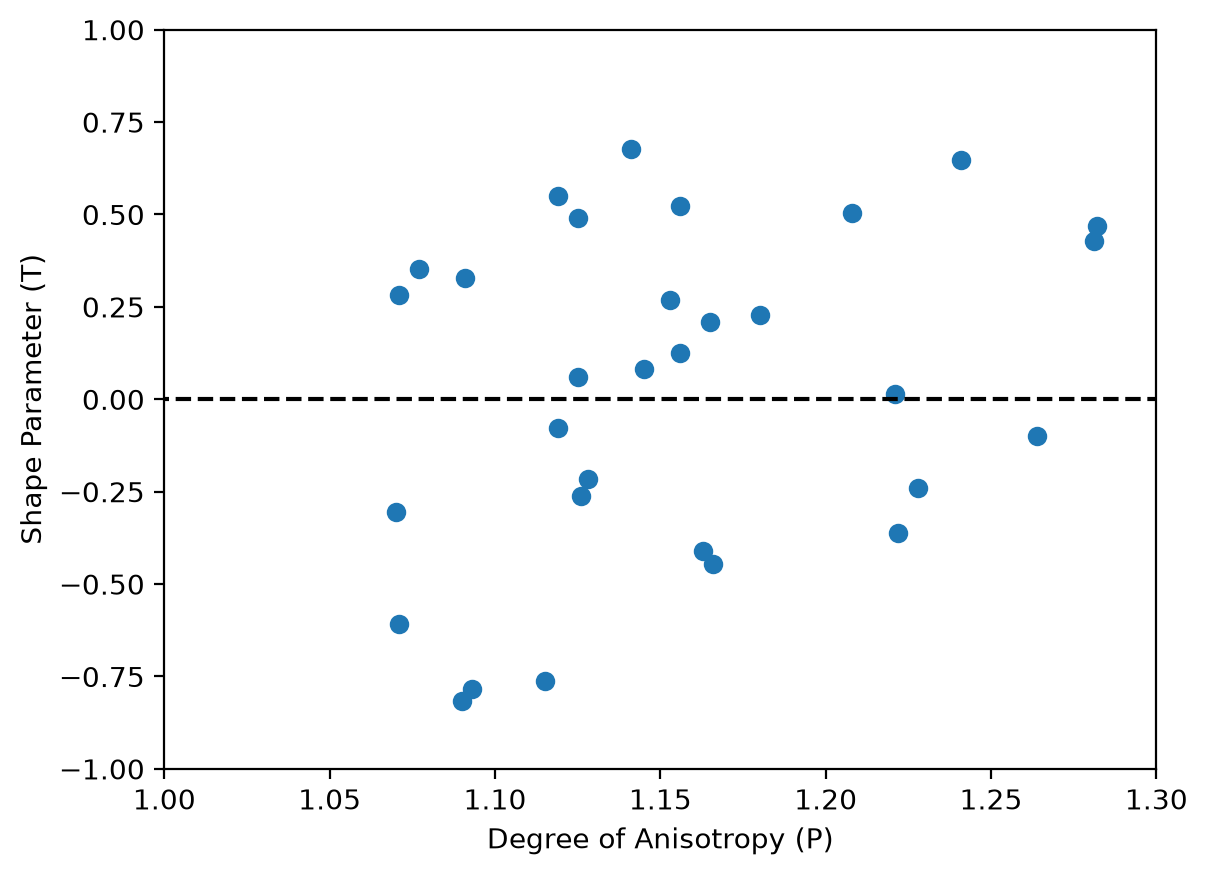

In [3]:
plt.scatter(specimens['aniso_p'],specimens['aniso_t'])
plt.xlim(1,1.3)
plt.ylim(-1,1)
plt.ylabel('Shape Parameter (T)')
plt.xlabel('Degree of Anisotropy (P)')
plt.hlines(y=0,xmin=0,xmax=1.3,linestyle='--',colors='black')
plt.show()

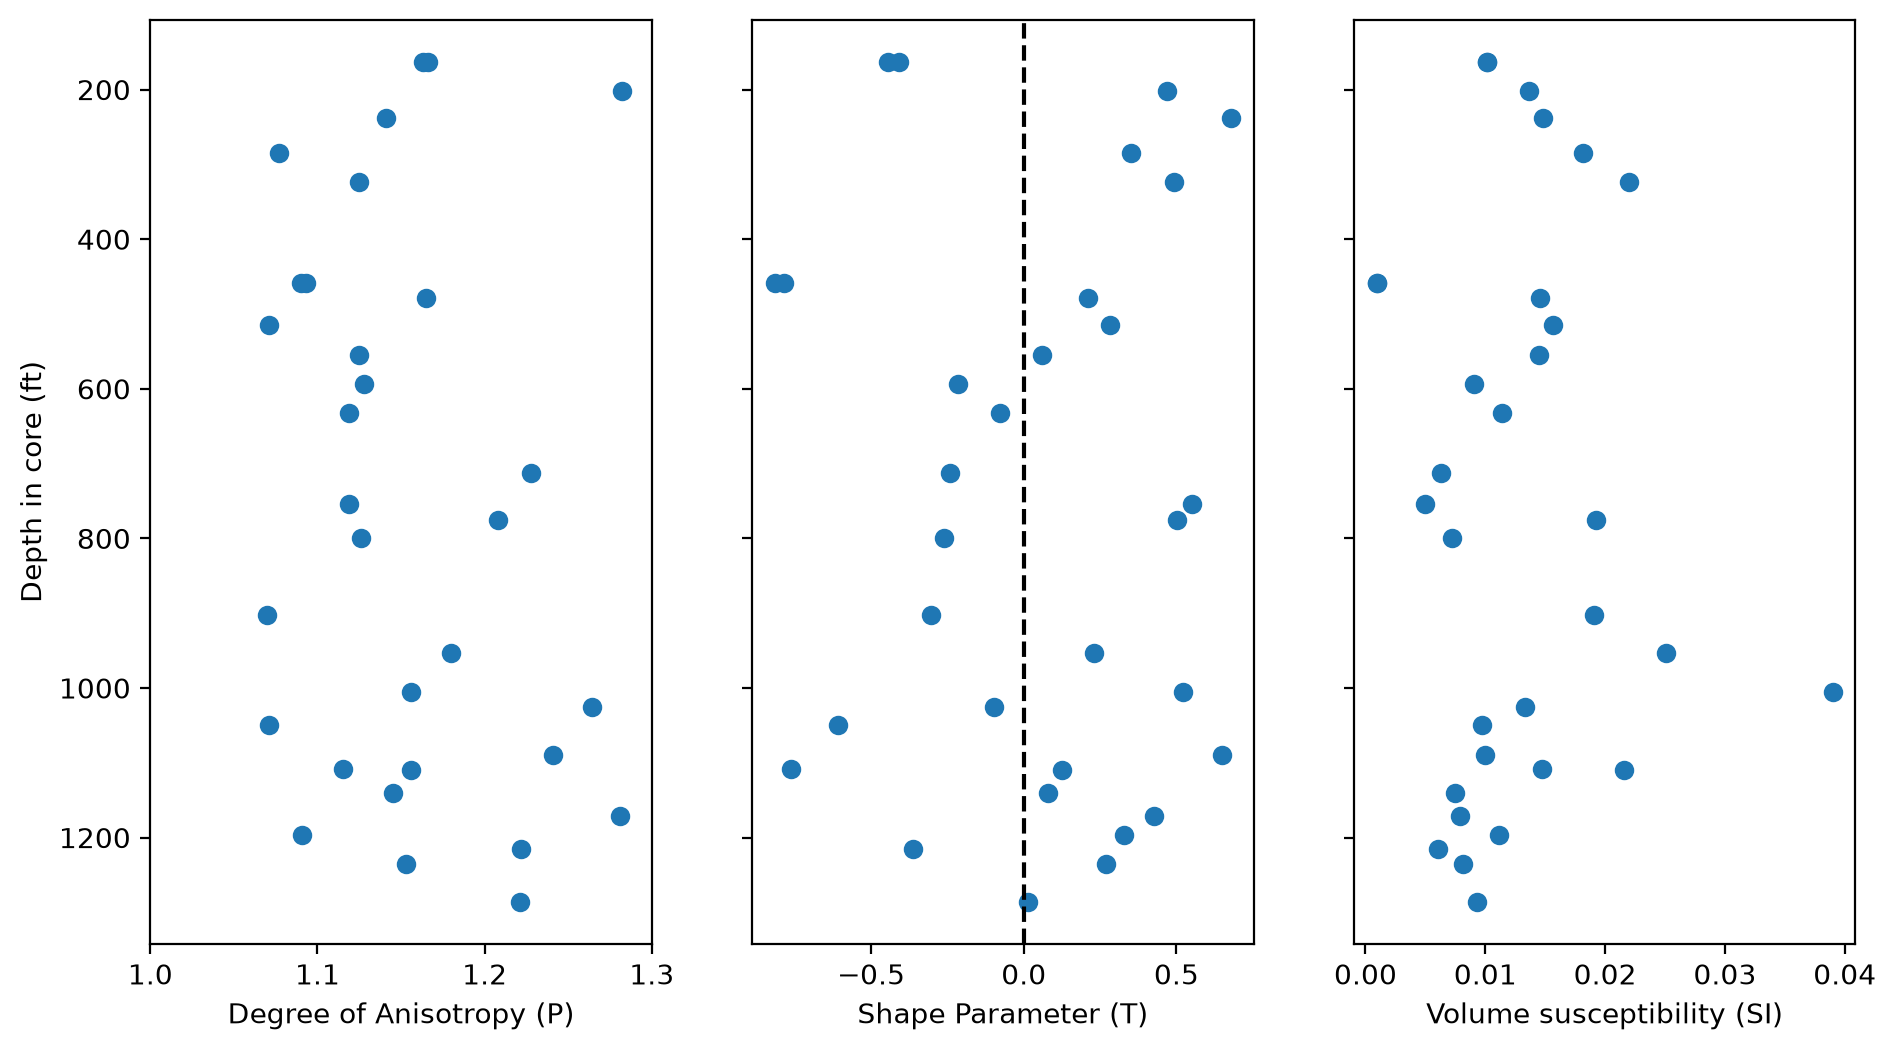

In [4]:
depth = specimens['specimen'].str.extract(r'D6A-(\d+)').astype(float)

# tensor mean (c11 + c22 + c33) / 3, converted from the exported 1e-6 SI to
# SI volume susceptibility; computed before the trace normalization below
aniso_s_mean = [1e-6 * sum(float(v) for v in value.split(':')[:3]) / 3
                for value in specimens['aniso_s']]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 6), sharey=True)

ax1.scatter(specimens['aniso_p'], depth)
ax1.invert_yaxis()
ax1.set_xlabel('Degree of Anisotropy (P)')
ax1.set_ylabel('Depth in core (ft)')
ax1.set_xlim(1.0,1.3)

ax2.scatter(specimens['aniso_t'], depth)
ax2.axvline(0, linestyle='--', color='black')
ax2.set_xlabel('Shape Parameter (T)')

ax3.scatter(aniso_s_mean, depth)
ax3.set_xlabel('Volume susceptibility (SI)')

plt.show()

## Normalize the tensor elements

The exported `aniso_s` values are volume susceptibilities in units of $10^{-6}$ SI (see the note in the introduction) rather than normalized by the tensor trace, which is the convention that PmagPy expects — `ipmag.plot_aniso` drops any specimen whose first element exceeds 1, so without normalization every specimen is excluded and the plots come back empty. Dividing the six elements by the trace fixes this.

In [5]:
specimens['aniso_s']['D6A-1005a']

'36390:40880:39670:608.099975585938:-436.600006103516:-1563'

In [6]:
def normalize_aniso_s(value):
    """Normalize a colon-delimited aniso_s tensor string by its trace.

    The six elements are s11, s22, s33, s12, s23, s13. Dividing all six by
    the trace (s11 + s22 + s33) gives the MagIC convention that PmagPy
    expects, with the normalized diagonal elements summing to 1. The
    eigenvectors and the anisotropy shape are unchanged by the rescaling.

    Args:
        value: aniso_s string, e.g. '36390:40880:39670:608.1:-436.6:-1563'.

    Returns:
        Colon-delimited string of the six trace-normalized elements.
    """
    s = [float(v) for v in value.split(':')]
    trace = s[0] + s[1] + s[2]
    return ':'.join(f'{v / trace}' for v in s)

In [7]:
normalize_aniso_s(specimens['aniso_s']['D6A-1005a'])

'0.3111852231913802:0.3495809817000171:0.3392337951086027:0.005200102407952266:-0.0037335386189799556:-0.013365828630066702'

In [8]:
specimens['aniso_s'] = specimens['aniso_s'].map(normalize_aniso_s)

## Rotate the tensors into geographic coordinates

The exported `aniso_s` tensors are in specimen coordinates. The samples table carries the orientations (azimuth 0, dip $-90$ for most of these cores, $-180$ for a few, following the conventions for how they were acquired), and `pmag.dosgeo` rotates each normalized tensor into geographic coordinates. The rotation preserves the eigenvalues, so the shape parameters are unchanged.

Two specimens (D6A-163a and D6A-459a) were measured twice, so the table holds 31 AMS rows for 29 specimens; the loop below rotates each row, replicates included.

In [9]:
def rotate_aniso_s(aniso_s, azimuth, dip):
    s = [float(value) for value in aniso_s.split(':')]
    s_geographic = pmag.dosgeo(s, azimuth, dip)
    return ':'.join(str(value) for value in s_geographic)

rotated = []
for i in range(len(specimens)):
    sample = specimens['sample'].iloc[i]
    azimuth = samples.loc[sample, 'azimuth']
    dip = samples.loc[sample, 'dip']
    rotated.append(rotate_aniso_s(specimens['aniso_s'].iloc[i], azimuth, dip))
specimens['aniso_s'] = rotated

In [10]:
specimens.head()

,aniso_f,aniso_l,aniso_p,aniso_s,aniso_s_n_measurements,aniso_t,aniso_type,azimuth,citations,contribution_id,...,rem_sratio,rem_sratio_back,rem_sratio_forward,result_quality,row_id,sample,specimen,synthetic_alternatives,volume,weight
specimen name,,,,,,,,,,,,,,,,,,,,,
D6A-1005a,1.117,1.035,1.156,0.3392338:0.34958097:0.3111852:-0.0037335386:-...,192.0,0.523,AMS,NaN,This Study,NaN,...,NaN,NaN,NaN,NaN,NaN,D6A-1005,D6A-1005a,NaN,NaN,NaN
D6A-1025a,1.111,1.137,1.264,0.3378446:0.36365914:0.29849625:-0.018834587:0...,192.0,-0.098,AMS,NaN,This Study,NaN,...,NaN,NaN,NaN,NaN,NaN,D6A-1025,D6A-1025a,NaN,NaN,NaN
D6A-1050a,1.013,1.056,1.071,0.32979342:0.32497865:0.34522793:-0.0014666212...,192.0,-0.609,AMS,NaN,This Study,NaN,...,NaN,NaN,NaN,NaN,NaN,D6A-1050,D6A-1050a,NaN,NaN,NaN
D6A-1089a,1.195,1.039,1.241,0.32468617:0.3575721:0.31774172:0.008667201:0....,192.0,0.648,AMS,NaN,This Study,NaN,...,NaN,NaN,NaN,NaN,NaN,D6A-1089,D6A-1089a,NaN,NaN,NaN
D6A-1108a,1.013,1.101,1.115,0.34692952:0.32902786:0.3240426:0.014099252:0....,192.0,-0.762,AMS,NaN,This Study,NaN,...,NaN,NaN,NaN,NaN,NaN,D6A-1108,D6A-1108a,NaN,NaN,NaN


## Principal directions

Equal-area projection of the principal susceptibility axes for all specimens (squares: $k_1$, maximum; triangles: $k_2$, intermediate; circles: $k_3$, minimum) — in geographic coordinates after the rotation above (plunges meaningful; azimuths relative, since the core is unoriented in azimuth).

The mean-tensor and confidence-ellipse figure that `plot_aniso` draws by default is suppressed with `plot_mean=False`: mean directions are not meaningful for an unoriented core.

{'data': 1}

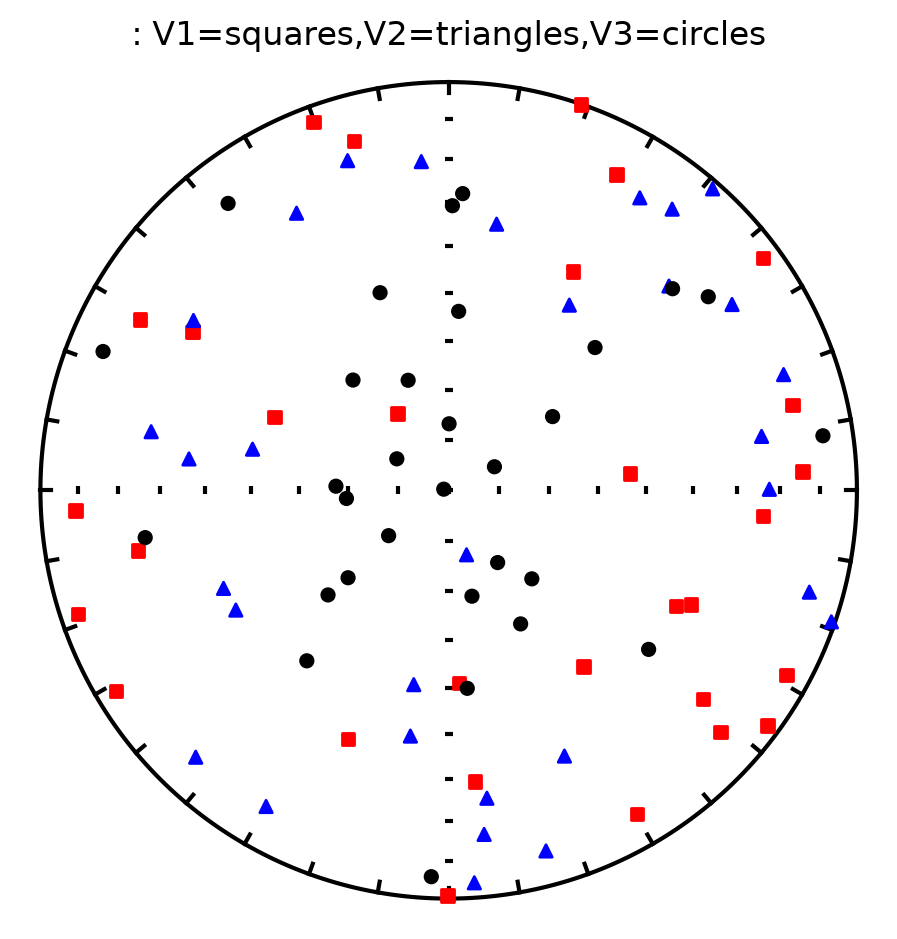

In [11]:
ipmag.plot_aniso(fignum=1, aniso_df=specimens, plot_mean=False)

## Fabric shape colored by $V_3$ plunge

Coloring the fabric-shape plot by the plunge of each specimen's minimum axis connects shape to orientation: the oblate specimens generally carry steeply plunging $V_3$ axes — a sub-horizontal foliation.

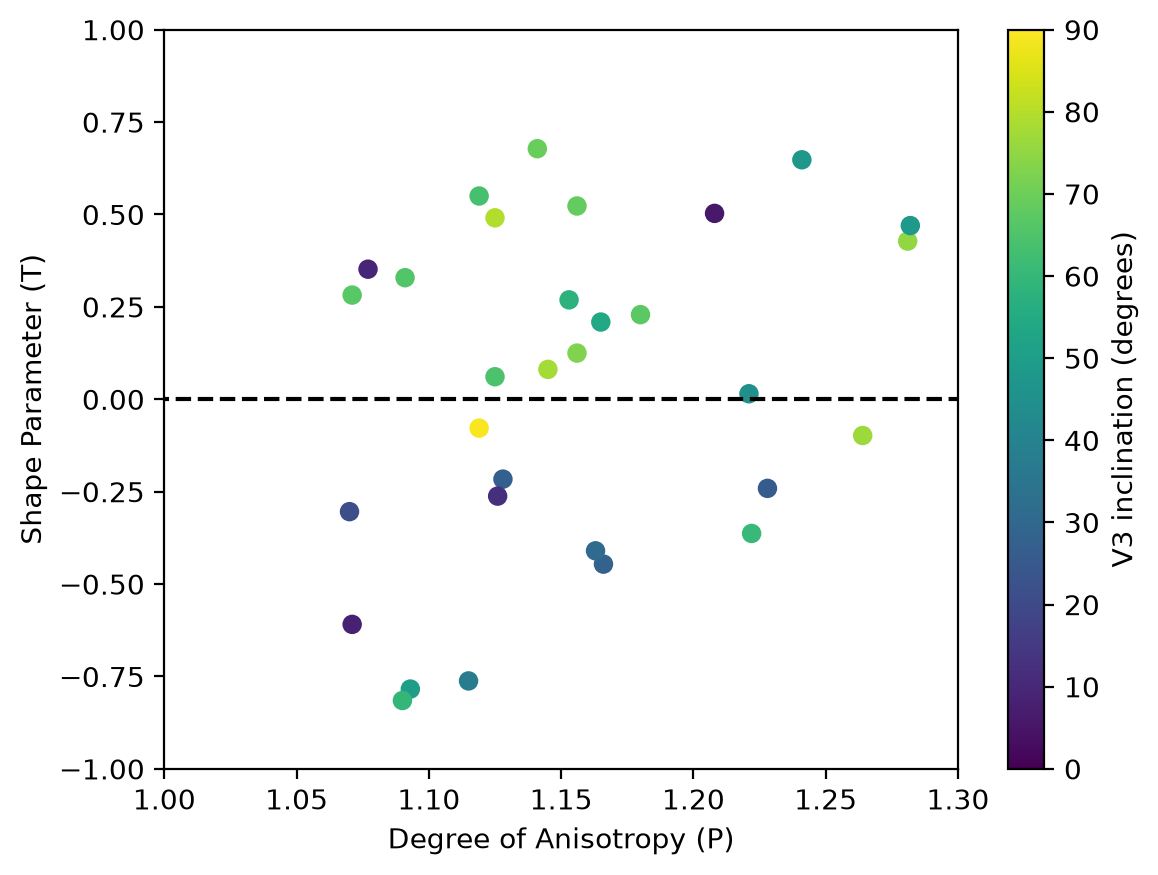

In [12]:
V3_inclination = []
for i in range(len(specimens)):
    s = [float(value) for value in specimens['aniso_s'].iloc[i].split(':')]
    tau, V = pmag.doseigs(s)
    V3_inclination.append(V[2][1])
specimens['V3_inclination'] = V3_inclination

plt.scatter(specimens['aniso_p'], specimens['aniso_t'],
            c=specimens['V3_inclination'], cmap='viridis', vmin=0, vmax=90)
plt.colorbar(label='V3 inclination (degrees)')
plt.xlim(1,1.3)
plt.ylim(-1,1)
plt.ylabel('Shape Parameter (T)')
plt.xlabel('Degree of Anisotropy (P)')
plt.hlines(y=0,xmin=0,xmax=1.3,linestyle='--',colors='black')
plt.show()

The specimens with oblate fabrics ($T > 0$):

In [13]:
oblate_specimens = specimens[specimens['aniso_t']>0]

{'data': 1}

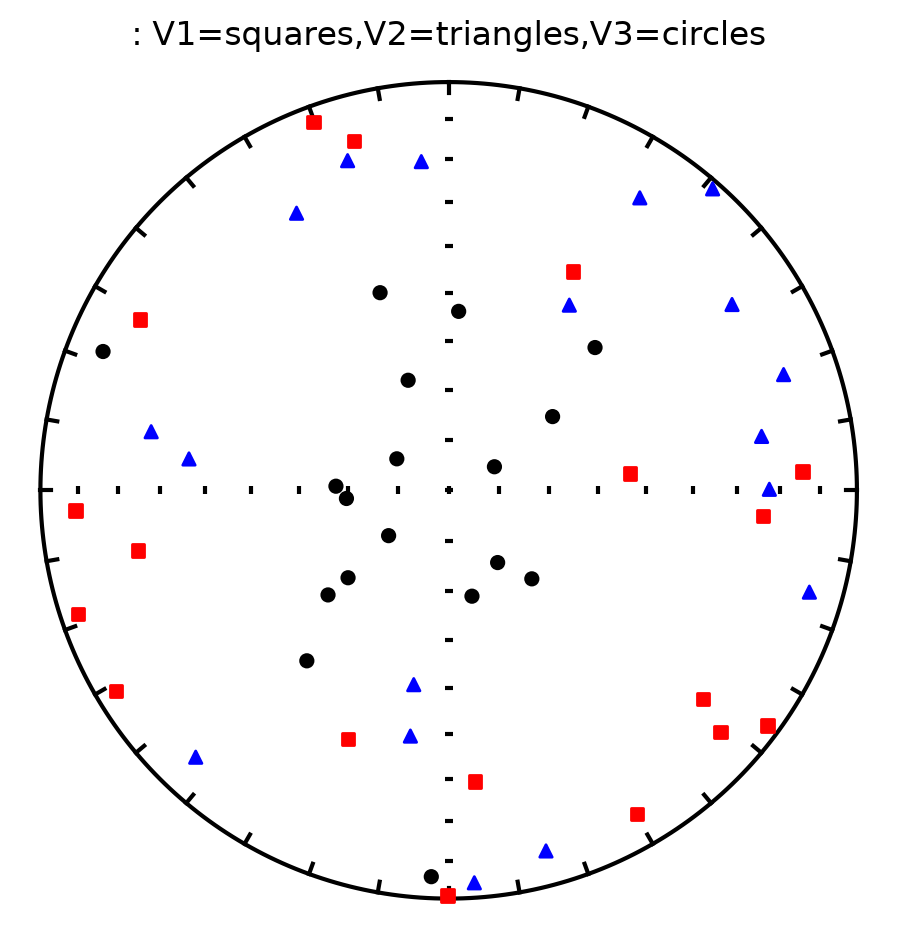

In [14]:
ipmag.plot_aniso(fignum=1, aniso_df=oblate_specimens, plot_mean=False)

## Inclination-only mean of the oblate $k_{min}$ directions

Because the core is unoriented in azimuth, only the plunges of the principal axes carry meaning. The mean plunge of the oblate specimens' $k_{min}$ axes is estimated with the maximum likelihood method of Arason and Levi (2010, doi:10.1111/j.1365-246X.2010.04671.x), implemented as `pmag.doincfish(inc, method='arason_levi')` — the method of choice for steep inclination-only data.

The estimator assumes a single Fisher population, and the two shallow-$k_{min}$ specimens (D6A-775a and D6A-285a; the dark points in the colored fabric-shape plot above, marked with crosses in the plot below) record a differently oriented fabric: they are excluded from the mean, since including them drags the precision parameter low enough that the likelihood maximum runs to the vertical. A mean $k_{min}$ plunge near 67° corresponds to a magnetic foliation dipping roughly 23° — consistent with gently dipping igneous layering intersected by the near-vertical hole.

In [15]:
steep_oblate = oblate_specimens[oblate_specimens['V3_inclination'] > 30]
print('number of specimens =', len(steep_oblate),
      '(two shallow k_min outliers excluded)')

arason = pmag.doincfish(steep_oblate['V3_inclination'], method='arason_levi')
print('mean inclination =', round(arason['inc'], 1), 'degrees')
print('alpha95 =', round(arason['alpha95'], 1), 'degrees')
print('kappa =', round(arason['k'], 1))
print('95% profile confidence =', round(arason['profile_lower_confidence_limit'], 1),
      'to', round(arason['profile_upper_confidence_limit'], 1), 'degrees')

number of specimens = 16 (two shallow k_min outliers excluded)
mean inclination = 67.0 degrees
alpha95 = 7.5 degrees
kappa = 25.3
95% profile confidence = 60.9 to 90.0 degrees


## $k_{min}$ axes against the tilt expectation

The AGT section is interpreted to have been tilted by about 15--20° from its original attitude. If the magnetic foliation formed horizontal — cumulate layering with the minimum susceptibility axis $k_{min}$ (= $V_3$, the pole to the foliation) vertical — and was then tilted with the section, the $k_{min}$ axes should now plunge 70--75°. Because the tilt direction is unknown and the core is unoriented in azimuth, the complete expectation is not a single direction but a small circle around the vertical: the $k_{min}$ axes should fall in the shaded band between the small circles drawn 15° and 20° from the center of the net (inclinations of 75° and 70°). Only the oblate specimens are plotted; the two shallow-$k_{min}$ specimens excluded from the inclination-only mean are marked with crosses. The dashed circle marks the Arason and Levi mean plunge of the steep cluster.

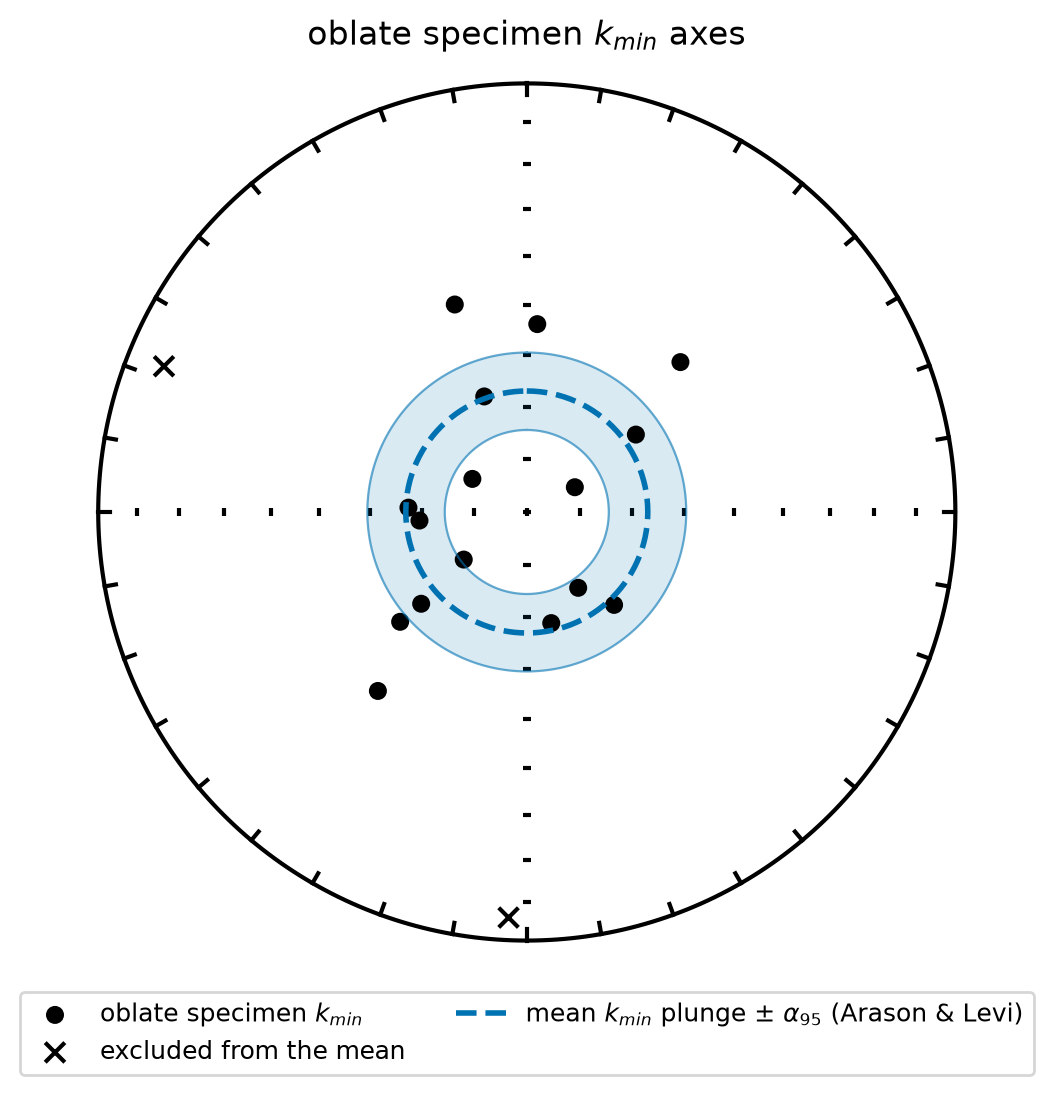

In [16]:
import numpy as np

def inclination_small_circle(inc):
    """Equal-area (x, y) coordinates of a constant-inclination small circle."""
    xy = np.array([pmag.dimap(dec, inc) for dec in np.linspace(0., 360., 361)])
    return xy[:, 0], xy[:, 1]

def plot_kmin_axes():
    """Plot the oblate specimen k_min axes on an equal-area net, with the
    Arason & Levi mean plunge and its alpha95 band; the two shallow
    specimens excluded from the mean are marked with crosses."""
    steep_dec, steep_inc = [], []
    excluded_dec, excluded_inc = [], []
    for i in range(len(oblate_specimens)):
        s = [float(value) for value in oblate_specimens['aniso_s'].iloc[i].split(':')]
        tau, V = pmag.doseigs(s)
        if V[2][1] > 30:
            steep_dec.append(V[2][0])
            steep_inc.append(V[2][1])
        else:
            excluded_dec.append(V[2][0])
            excluded_inc.append(V[2][1])

    ipmag.plot_net(1)
    ipmag.plot_di(dec=steep_dec, inc=steep_inc, color='k', marker='o',
                  markersize=30, label='oblate specimen $k_{min}$')
    ipmag.plot_di(dec=excluded_dec, inc=excluded_inc, color='k', marker='x',
                  markersize=50, label='excluded from the mean')

    x_mean, y_mean = inclination_small_circle(arason['inc'])
    plt.plot(x_mean, y_mean, color='#0072B2', lw=2, ls='--',
             label='mean $k_{min}$ plunge $\\pm$ $\\alpha_{95}$ (Arason & Levi)')
    x_lo, y_lo = inclination_small_circle(arason['inc'] - arason['alpha95'])
    x_hi, y_hi = inclination_small_circle(arason['inc'] + arason['alpha95'])
    plt.fill(np.concatenate([x_lo, x_hi[::-1]]), np.concatenate([y_lo, y_hi[::-1]]),
             color='#0072B2', alpha=0.15, lw=0)
    plt.plot(x_lo, y_lo, color='#0072B2', lw=0.8, alpha=0.6)
    plt.plot(x_hi, y_hi, color='#0072B2', lw=0.8, alpha=0.6)

plot_kmin_axes()
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2,
           fontsize=9)
plt.title('oblate specimen $k_{min}$ axes')
plt.show()

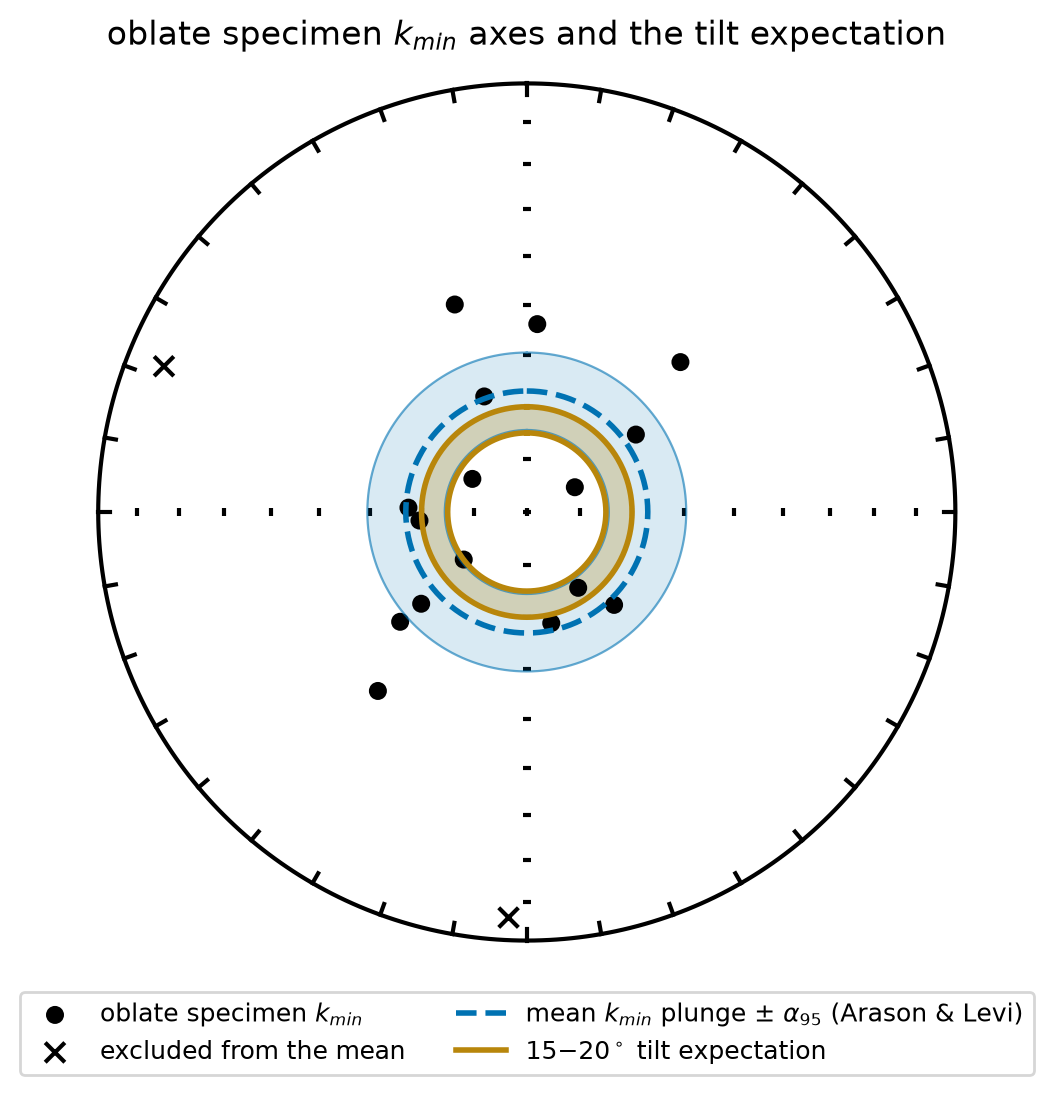

In [17]:
plot_kmin_axes()

x70, y70 = inclination_small_circle(70)
x75, y75 = inclination_small_circle(75)
plt.fill(np.concatenate([x70, x75[::-1]]), np.concatenate([y70, y75[::-1]]),
         color='#b8860b', alpha=0.25, lw=0)
plt.plot(x70, y70, color='#b8860b', lw=2,
         label='15$-$20$^\\circ$ tilt expectation')
plt.plot(x75, y75, color='#b8860b', lw=2)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2,
           fontsize=9)
plt.title('oblate specimen $k_{min}$ axes and the tilt expectation')
plt.show()